## Imports

In [1]:
import itertools

import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
import numpy as np
import pandas as pd
import seaborn as sns

from matplotlib.lines import Line2D
from scipy.spatial.distance import cdist
from scipy.stats import wilcoxon

from analysis_helpers import Episode, Participant
from analysis_helpers.constants import FIG_DIR
from analysis_helpers.functions import (
    dtw, 
    format_stats, 
    mean_center, 
    show_source
)

## Functions

In [2]:
show_source(dtw)

In [3]:
show_source(mean_center)

In [4]:
show_source(format_stats)

In [5]:
def _blend_white(color, amount):
    """
    Blend a color towards white (lighten + desaturate) by an amount in [0, 1]
    """
    rgb = np.array(mcolors.to_rgb(color))
    return tuple(rgb + (1.0 - rgb) * amount)

In [6]:
def draw_dtw_matches(ax, path_a, path_b, warp_path):
    for a_ix, b_ix in warp_path:
        ax.plot([path_a[a_ix, 0], path_b[b_ix, 0]], 
                [path_a[a_ix, 1], path_b[b_ix, 1]],
                color=WARP_LINE_COLOR, 
                alpha=WARP_LINE_ALPHA, 
                lw=WARP_LINEWIDTH, 
                zorder=1, 
                solid_capstyle="round")
    return ax

In [7]:
def draw_event_path(ax, path, color, offset=(0.0, 0.0), back=False, shadow=False):
    """A single event-path. `back=True` makes it recede (offset, lighter, smaller,
    lower); `shadow=True` casts a soft drop-shadow so the front path floats above."""
    pts = np.asarray(path) + np.asarray(offset)

    if back:
        color = _blend_white(color, BACK_LIGHTEN)
        lw = PATH_LINEWIDTH * BACK_LW_SCALE
        casing = lw + BACK_CASING_EXTRA
        markersize = EVENT_MARKERSIZE * BACK_MARKER_SCALE
        z_line, z_mark = 2.0, 2.6
    else:
        lw = PATH_LINEWIDTH
        casing = PATH_CASING_WIDTH
        markersize = EVENT_MARKERSIZE
        z_line, z_mark = 4.0, 6.0

    effects = [pe.Stroke(linewidth=casing, foreground="white"), pe.Normal()]
    if shadow:
        effects = [pe.SimpleLineShadow(offset=SHADOW_OFFSET,
                                       shadow_color=SHADOW_COLOR,
                                       alpha=SHADOW_ALPHA,
                                       rho=1.0)] + effects

    ax.plot(pts[:, 0], pts[:, 1], "-",
            color=color, 
            lw=lw, 
            zorder=z_line,
            solid_capstyle="round", 
            solid_joinstyle="round",
            path_effects=effects)
    ax.scatter(pts[:, 0], pts[:, 1],
               s=markersize, 
               color=color, 
               zorder=z_mark,
               edgecolor="white", 
               linewidth=EVENT_BORDER_WIDTH)
    return ax

In [15]:
# def draw_offset_indicator(ax, offset):
#     """Small key in the bottom-right showing the true-scale direction/magnitude of
#     the depth offset: a dot at a point's real position, an arrow to where it is drawn."""
#     span = max(xlim_max - xlim_min, ylim_max - ylim_min)
#     margin = 0.07 * span
#     disp = np.array([xlim_max - margin, ylim_min + margin])   # as-drawn (displaced) end
#     true_ = disp - np.asarray(offset)                          # real position end

#     ax.annotate("", xy=tuple(disp), xytext=tuple(true_),
#                 arrowprops=dict(arrowstyle="-|>", color=OFFSET_IND_COLOR,
#                                 lw=1.3, shrinkA=0, shrinkB=0),
#                 zorder=8)
#     ax.scatter(*true_, s=26, color=OFFSET_IND_COLOR,
#                edgecolor="white", linewidth=0.8, zorder=8)
#     ax.text((true_[0] + disp[0]) / 2, max(true_[1], disp[1]) + 0.025 * span,
#             OFFSET_IND_LABEL, ha="center", va="bottom",
#             fontsize=8.5, color=OFFSET_IND_COLOR, zorder=8,
#             bbox=dict(boxstyle="round,pad=0.25", fc="white", ec="none", alpha=0.7))
#     return ax

def draw_offset_indicator(ax, offset):
    span = max(xlim_max - xlim_min, ylim_max - ylim_min)
    margin = 0.07 * span
    disp = np.array([xlim_max - margin, ylim_min + margin])
    true_ = disp - np.asarray(offset)
    ax.annotate("", xy=tuple(disp), xytext=tuple(true_),
                arrowprops=dict(arrowstyle="-|>", color=OFFSET_IND_COLOR,
                                lw=OFFSET_IND_ARROW_LW, shrinkA=0, shrinkB=0), zorder=8)
    ax.scatter(*true_, s=OFFSET_IND_DOT_SIZE, color=OFFSET_IND_COLOR, edgecolor="white",
               linewidth=0.8, zorder=8)
    ax.text((true_[0] + disp[0]) / 2, max(true_[1], disp[1]) + 0.025 * span,
            OFFSET_IND_LABEL, ha="center", va="bottom", fontsize=OFFSET_IND_FONTSIZE,
            color=OFFSET_IND_COLOR, zorder=8,
            bbox=dict(boxstyle="round,pad=0.25", fc="white", ec="none", alpha=0.7))
    return ax

In [54]:
def style_traj_panel(ax, letter, title, dist):
    ax.set_xlim(xlim_min, xlim_max)
    ax.set_ylim(ylim_min, ylim_max)
    ax.set(adjustable='box', aspect='equal', xticks=[], yticks=[])
    ax.spines[['top', 'right']].set_visible(False)
    ax.set_title(letter, loc='left', fontweight='bold', fontsize=PANEL_LETTER_FONTSIZE)
    ax.set_title(title, loc='center', fontsize=TITLE_FONTSIZE, pad=TITLE_YPAD)
    ax.text(TEXTBOX_X, TEXTBOX_Y, f'mean warp cost = {dist:.3f}',
            transform=ax.transAxes, ha="left", va="top", fontsize=TEXTBOX_FONTSIZE,
            bbox={'boxstyle': 'round,pad=0.4', 'fc': 'white', 'ec': '#cccccc', 'lw': 0.8})


## Load data

In [9]:
atlep1 = Episode('atlep1')
participants = Participant.load_all()

In [10]:
ep_events_centered = atlep1.events - atlep1.events.mean(axis=0)

# center immediate & delayed recall on mean centroid to mitigate 
# person-specific register effects (idiolect, etc.)
imm_events_centered = []
del_events_centered = []
for p in participants:
    imm_centered, del_centered = mean_center(p.events['atlep1'], p.events['delayed'])
    imm_events_centered.append(imm_centered)
    del_events_centered.append(del_centered)

## Is delayed recall more similar to own immediate recall than to episode?

In [11]:
warp_dists_imm = []
warp_dists_episode = []

for imm_events, del_events in zip(imm_events_centered, del_events_centered):
    dist_imm = dtw(del_events, imm_events)[0]
    dist_ep = dtw(del_events, ep_events_centered)[0]
    warp_dists_imm.append(dist_imm)
    warp_dists_episode.append(dist_ep)
    
T, p = wilcoxon(warp_dists_episode, warp_dists_imm, alternative='greater')
T, p = T.item(), p.item()
print(f'mean immediate-alignment cost: {np.mean(warp_dists_imm):.4f}')
print(f'mean episode-alignment cost: {np.mean(warp_dists_episode):.4f}')
print(f'{T=}, {p=:.4e}')

mean immediate-alignment cost: 0.5321
mean episode-alignment cost: 0.6539
T=1430.0, p=1.2637e-10


In [143]:
# self_vs_episode_data = {
#     'warp_dists_imm': warp_dists_imm,
#     'warp_dists_episode': warp_dists_episode
# }
# with open('self_vs_episode_data.p', 'wb') as f:
#     pickle.dump(self_vs_episode_data, f)

In [151]:
# df = pd.DataFrame(columns=('Comparison', 'participant', 'Warp distance'))
# df['Comparison'] = np.repeat(['delayed-->immediate', 'delayed-->episode'], len(participants))
# df['participant'] = np.tile(np.arange(1, len(participants) + 1), 2)
# df['Warp distance'] = np.concatenate((warp_dists_imm, warp_dists_episode))

# fig, ax = plt.subplots(1, figsize=(6, 6))
# ax = sns.violinplot(df, x='Comparison', y='Warp distance', hue='Comparison', split=True, gap=0.3)
# inner_boxplot_xshift = 0.01
# for line in ax.lines:
#     xdata = line.get_xdata()
#     center = np.mean(xdata)
#     direction = -1 if center < 0.5 else 1  # left vs right violin
#     line.set_xdata([x + direction * inner_boxplot_xshift for x in xdata])


# scatter_point_size = 10
# scatter_x_offset = 0.35
# connection_linewidth = 1
# connection_alpha = 0.5
# decrease_color = '#f9c74f'
# increase_color = '#6cd0d0'
# no_change_color = 'grey'

# imm_scatter_xcoords = np.zeros(len(warp_dists_imm)) + scatter_x_offset
# ep_scatter_xcoords = np.ones(len(warp_dists_episode)) - scatter_x_offset

# ax.scatter(imm_scatter_xcoords, 
#            warp_dists_imm, 
#            s=scatter_point_size, 
#            zorder=2)
# ax.scatter(ep_scatter_xcoords, 
#            warp_dists_episode, 
#            s=scatter_point_size, 
#            zorder=2)
# ax.plot([imm_scatter_xcoords, ep_scatter_xcoords], 
#         [warp_dists_imm, warp_dists_episode], 
#         c=no_change_color, 
#         alpha=connection_alpha, 
#         lw=connection_linewidth, 
#         zorder=1)

# for connection_line in ax.get_lines()[-len(participants):]:
#     y_imm, y_ep = connection_line.get_ydata()
#     if y_imm > y_ep:
#         connection_line.set_color(decrease_color)
#     elif y_imm < y_ep:
#         connection_line.set_color(increase_color)

# T, p = wilcoxon(warp_dists_episode, warp_dists_imm, alternative='greater')
# stat_text =  format_stats(T, p, 'T_w', n_decimals_stat=0)
# ax.text(0.8, 0.3, stat_text, fontsize='large')
# plt.show()

## Is delayed recall more similar to own immediate recall than to *others'* immediate recalls?

In [12]:
warp_dists_self = np.array(warp_dists_imm[:])
warp_dists_others = np.empty((len(participants), len(participants) - 1), dtype=float)

for i in range(len(participants)):
    del_events = del_events_centered[i]
    dists_ix = 0
    for j in range(len(participants)):
        if j != i:
            warp_dist_other = dtw(del_events, imm_events_centered[j])[0]
            warp_dists_others[i, dists_ix] = warp_dist_other
            dists_ix += 1
            
pct_ranks = np.empty_like(warp_dists_self)
for i, own in enumerate(warp_dists_self):
    others = warp_dists_others[i]
    pct_ranks[i] = ((own < others).sum() + (own == others).sum() * 0.5) / len(others)
    
print(wilcoxon(pct_ranks, 0.5, alternative='greater'))

WilcoxonResult(statistic=np.float64(1431.0), pvalue=np.float64(2.182214068738512e-11))


## Construct figure

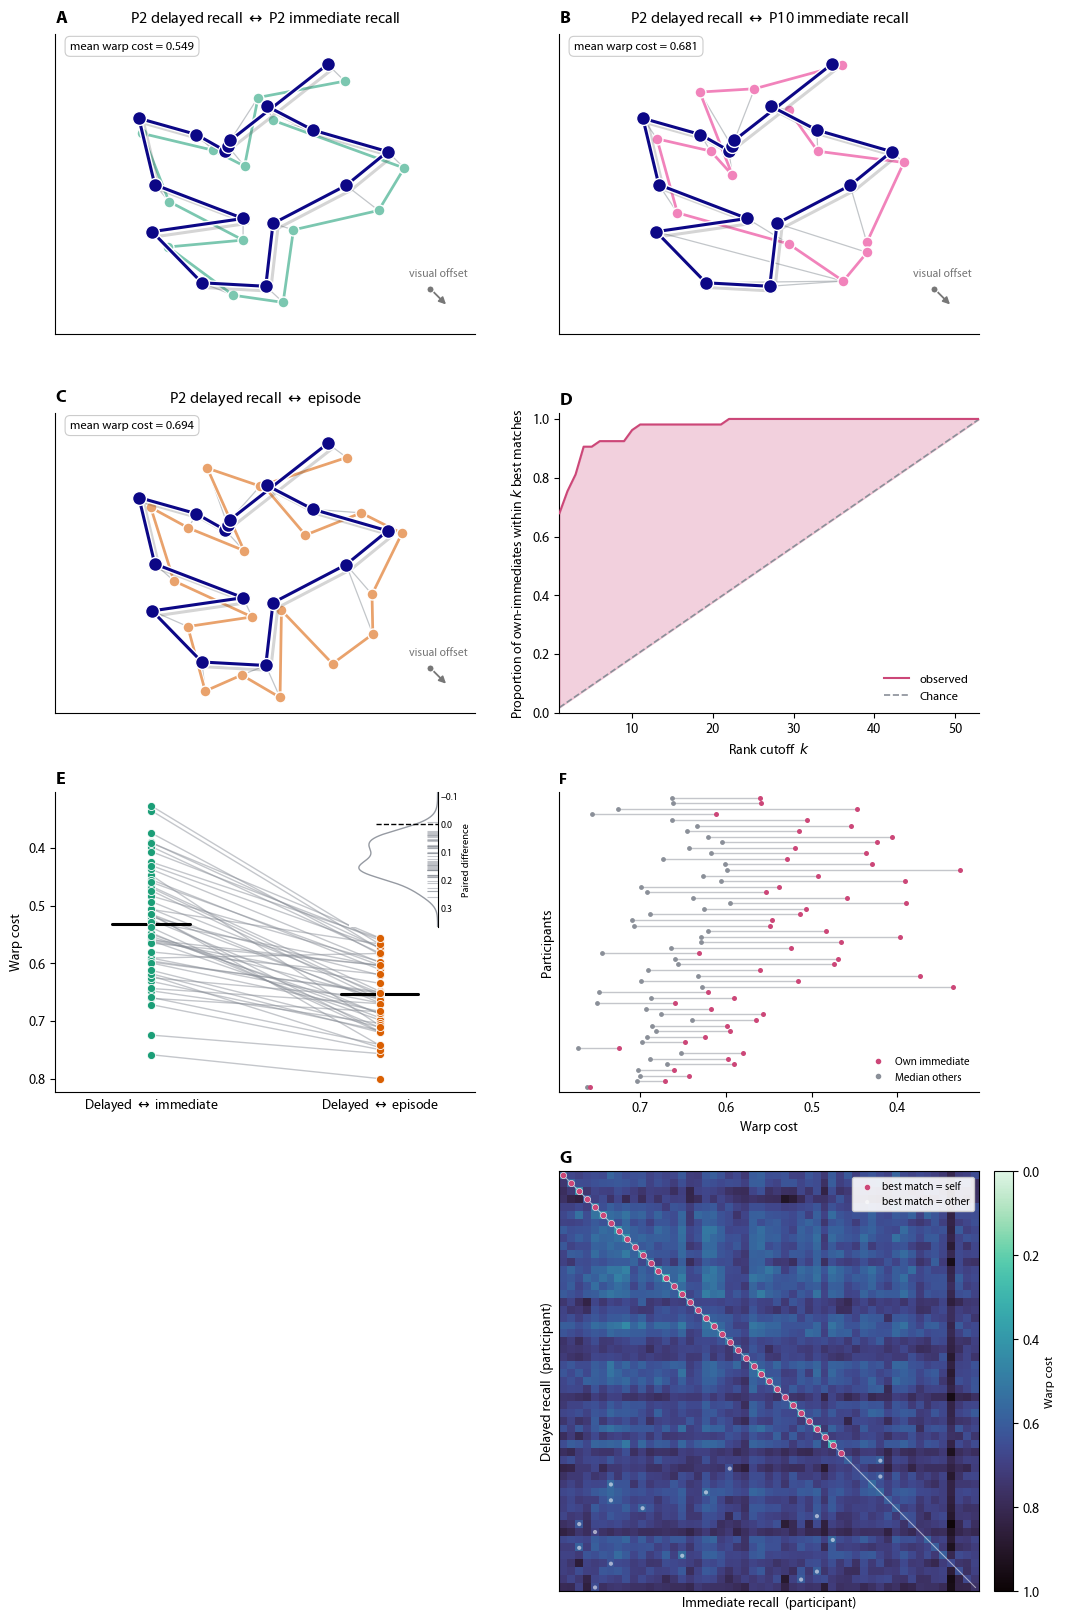

In [87]:
import pickle
from scipy.stats import gaussian_kde

# ======================================================================
# DATA
# ======================================================================
with open('panel_data.p', 'rb') as f:
    D = pickle.load(f)

del_path       = np.asarray(D['del_path'])
own_imm_path   = np.asarray(D['own_imm_path'])
other_imm_path = np.asarray(D['other_imm_path'])
episode_path   = np.asarray(D['episode_path'])
own_imm_warp   = D['own_imm_warp']
other_imm_warp = D['other_imm_warp']
episode_warp   = D['episode_warp']
own_imm_dist   = D['own_imm_dist']
other_imm_dist = D['other_imm_dist']
episode_dist   = D['episode_dist']

warp_dists = np.load('warp_dists.npy')

with open('self_vs_episode_data.p', 'rb') as f:
    SE = pickle.load(f)
sve_imm = np.asarray(SE['warp_dists_imm'], float)       # delayed <-> own immediate
sve_ep  = np.asarray(SE['warp_dists_episode'], float)   # delayed <-> episode

MAIN_PARTICIPANT_N = 2
OTHER_PARTICIPANT_N = 10
main_pid  = f'P{MAIN_PARTICIPANT_N}'
other_pid = f'P{OTHER_PARTICIPANT_N}'

# ======================================================================
# CONFIG  (everything tweakable lives here)
# ======================================================================

# ---- shared colors (referenced across multiple panels) ---------------
MAIN_DEL_COLOR   = "#0c0786"   # delayed recall (trajectory front path; legend)
MAIN_IMM_COLOR   = "#1B9E77"   # own immediate  (trajectory A back path; slope-E own dots)
OTHER_IMM_COLOR  = "#E7298A"   # other immediate (trajectory B back path)
EPISODE_COLOR    = "#D95F02"   # episode        (trajectory C back path; slope-E episode dots)
WARP_LINE_COLOR  = "#9AA0A6"   # DTW match lines (trajectories)
SURR_COLOR       = "#8a8f98"   # surrogate / neutral grey (D chance line, E & F connectors, F median dots)
SELF_COLOR       = "#cc4778"   # "self / observed" accent (D observed line+fill+point, F own dots, G self dots)
SELF_MUTED_COLOR = "#c9ccd1"   # F: own dot when it is worse than the surrogate median

# ---- connectors shared by panels E and F -----------------------------
CONNECTOR_COLOR = SURR_COLOR
CONNECTOR_ALPHA = 0.5
CONNECTOR_LW    = 1.0

# ---- panel letters ---------------------------------------------------
PANEL_LETTER_FONTSIZE = 13

# ---- trajectory panels (A, B, C) -------------------------------------
EVENT_MARKERSIZE   = 100
EVENT_BORDER_WIDTH = 1
PATH_LINEWIDTH     = 2.2
PATH_CASING_WIDTH  = PATH_LINEWIDTH + 2
WARP_LINEWIDTH     = 0.9
WARP_LINE_ALPHA    = 0.6

DEPTH_OFFSET      = (5.0, -5.0)   # (dx, dy) shift of the receding "back" path
BACK_LIGHTEN      = 0.42          # 0 = full colour, 1 = white
BACK_LW_SCALE     = 0.9
BACK_MARKER_SCALE = 0.62
BACK_CASING_EXTRA = 1.5
SHADOW_OFFSET     = (3.5, -3.5)
SHADOW_COLOR      = "#404040"
SHADOW_ALPHA      = 0.22

SHOW_OFFSET_INDICATOR = True
OFFSET_IND_COLOR      = "#777777"
OFFSET_IND_LABEL      = "visual offset"
OFFSET_IND_ARROW_LW   = 1.3
OFFSET_IND_DOT_SIZE   = 26
OFFSET_IND_FONTSIZE   = 8.5

XLIM_PAD         = 5
YLIM_PAD         = 5
TITLE_FONTSIZE   = 11.5           # trajectory centered (descriptive) title
TITLE_YPAD       = 8
TEXTBOX_X        = 0.035
TEXTBOX_Y        = 0.975
TEXTBOX_FONTSIZE = 9

# ---- panel D: fingerprinting accuracy curve --------------------------
ACC_LINE_COLOR      = SELF_COLOR
ACC_LINE_WIDTH      = 1.5
ACC_FILL_ALPHA      = 0.25        # fill uses SELF_COLOR at this alpha
ACC_POINT_SIZE      = 45          # highlighted k=1 marker
CHANCE_LINE_COLOR   = SURR_COLOR
CHANCE_LINE_WIDTH   = 1.2
ACC_LEGEND_FONTSIZE = 9

# ---- panel E: self-vs-episode paired slope plot ----------------------
SLOPE_X          = (0.0, 1.0)     # x positions of the (own-immediate, episode) columns
SLOPE_XLIM       = (-0.42, 1.42)
SLOPE_DOT_SIZE   = 34
SLOPE_DOT_EDGE_W = 0.6
SLOPE_OWN_COLOR  = MAIN_IMM_COLOR
SLOPE_EP_COLOR   = EPISODE_COLOR
MEAN_TICK_COLOR     = "black"
MEAN_TICK_LW        = 2.2
MEAN_TICK_HALFWIDTH = 0.17        # in x-data units
# panel-E difference inset (rug + one-sided KDE)
INSET_BBOX          = [0.70, 0.55, 0.21, 0.45]   # [x0, y0, w, h] in axNew-axes fraction
INSET_KDE_LW        = 1.0
INSET_KDE_ALPHA     = 0.9
INSET_RUG_LW        = 0.8
INSET_RUG_EXTENT    = 0.13        # leftward length of each rug tick (normalized-density units)
INSET_YPAD_FRAC     = 0.4        # y-limit padding as a fraction of the difference range
INSET_ZERO_LW       = 1.0
INSET_YTICKS        = [-0.1, 0.0, 0.1, 0.2, 0.3]
INSET_LABEL_FONTSIZE = 7.5
INSET_TICK_FONTSIZE  = 7

# ---- panel F: own immediate vs. surrogate median ---------------------
MED_DOT_SIZE     = 6              # surrogate median dot
F_OWN_DOT_SIZE   = 13             # own-immediate dot
F_OWN_EDGE_W     = 0
F_TITLE_FONTSIZE = 11

# ---- panel G: identification (fingerprint) matrix --------------------
HEATMAP_CMAP          = 'mako_r'
HEATMAP_CMAP_FALLBACK = 'viridis_r'
HEATMAP_VMIN          = 0.0
HEATMAP_VMAX          = 1.0
DIAG_LINE_COLOR = 'white'
DIAG_LINE_WIDTH = 0.8
DIAG_LINE_ALPHA = 0.55
MATCH_SELF_SIZE  = 20            # best-match-is-self markers (uses SELF_COLOR)
MATCH_SELF_EDGE_W = 0.4
MATCH_OTHER_SIZE = 9             # best-match-is-other markers
MATCH_OTHER_COLOR = 'white'
MATCH_OTHER_ALPHA = 0.55
COLORBAR_BBOX          = [1.035, 0.0, 0.045, 1.0]   # in axMat-axes fraction (sits outside the grid)
COLORBAR_LABEL_FONTSIZE = 9
G_LEGEND_FONTSIZE       = 8

# ---- figure layout / grid geometry -----------------------------------
# Rows 1-3 use CELL_ASPECT:1 cells; the bottom row is a taller SQUARE cell so the
# heatmap fills its full column width. Figure size is derived so each row keeps its
# exact inch height and the colorbar sits in the right margin, outside the grid.
NROWS, NCOLS = 4, 2
CELL_ASPECT  = 1.4               # cell width : height for rows 1-3
CELL_H       = 3.0               # cell height for rows 1-3 (inches)
CELL_W       = CELL_ASPECT * CELL_H          # column width (inches)
ROW_H        = [CELL_H, CELL_H, CELL_H, CELL_W]   # bottom row square
WSPACE, HSPACE = 0.20, 0.24      # gaps as a fraction of cell width / avg cell height
L_IN, R_IN, T_IN, B_IN = 0.85, 1.40, 0.35, 0.55   # figure margins (in); R_IN holds the colorbar



# ======================================================================
# COMPUTATIONS
# ======================================================================
# shared trajectory limits (include shifted back paths so nothing clips)
offset = np.asarray(DEPTH_OFFSET)
all_points = np.vstack((
    del_path, own_imm_path, other_imm_path, episode_path,
    del_path + offset, own_imm_path + offset,
    other_imm_path + offset, episode_path + offset,
))
xlim_min, ylim_min = all_points.min(axis=0)
xlim_max, ylim_max = all_points.max(axis=0)
xlim_min -= XLIM_PAD; xlim_max += XLIM_PAD
ylim_min -= YLIM_PAD; ylim_max += YLIM_PAD
# widen x-bounds symmetrically so equal-aspect trajectory axes match the cell ratio
_xc = 0.5 * (xlim_min + xlim_max)
_half = 0.5 * CELL_ASPECT * (ylim_max - ylim_min)
xlim_min, xlim_max = _xc - _half, _xc + _half

# fingerprint matrix + identification stats (panels D, F, G)
M = warp_dists
n = M.shape[0]
own = np.diag(M).copy()
pr = np.array([((own[i] > np.delete(M[i], i)).sum()
                + 0.5 * (own[i] == np.delete(M[i], i)).sum()) / (n - 1) for i in range(n)])
order = np.argsort(pr)                       # best-identified first -> top-left
ks = np.arange(1, n + 1)
chance = ks / n
below = np.array([(np.delete(M[i], i) < own[i]).sum() for i in range(n)])
ties = np.array([(np.delete(M[i], i) == own[i]).sum() for i in range(n)])
acc = np.array([np.mean(np.clip(k - below, 0, ties + 1) / (ties + 1)) for k in ks])

# ======================================================================
# FIGURE + LAYOUT  (4 rows x 2 cols)
#   (r1,c1) A own-imm traj     (r1,c2) B other-imm traj
#   (r2,c1) C episode traj     (r2,c2) D accuracy curve
#   (r3,c1) E slope plot       (r3,c2) F own-vs-median
#   (r4,c1) empty              (r4,c2) G heatmap
#   left col = analysis 1, right col = analysis 2
# ======================================================================
sum_h = sum(ROW_H)
plot_w = CELL_W * (NCOLS + (NCOLS - 1) * WSPACE)
plot_h = sum_h * (NROWS + (NROWS - 1) * HSPACE) / NROWS   # keeps each row at its ROW_H inches
fig_w = L_IN + plot_w + R_IN
fig_h = B_IN + plot_h + T_IN
fig = plt.figure(figsize=(fig_w, fig_h))
gs = fig.add_gridspec(NROWS, NCOLS,
                      left=L_IN / fig_w, right=1 - R_IN / fig_w,
                      bottom=B_IN / fig_h, top=1 - T_IN / fig_h,
                      wspace=WSPACE, hspace=HSPACE, height_ratios=ROW_H)

own_ax   = fig.add_subplot(gs[0, 0])
other_ax = fig.add_subplot(gs[0, 1], sharex=own_ax, sharey=own_ax)
ep_ax    = fig.add_subplot(gs[1, 0], sharex=own_ax, sharey=own_ax)
axAcc = fig.add_subplot(gs[1, 1])
axNew = fig.add_subplot(gs[2, 0])
axMed = fig.add_subplot(gs[2, 1])
axEmpty = fig.add_subplot(gs[3, 0]); axEmpty.axis('off')
axMat = fig.add_subplot(gs[3, 1])

# ---- trajectory panels (A, B, C) -------------------------------------
panels = [
    (own_ax,   'A', own_imm_path,   own_imm_warp,   MAIN_IMM_COLOR,
     fr'{main_pid} delayed recall $\leftrightarrow$ {main_pid} immediate recall', own_imm_dist),
    (other_ax, 'B', other_imm_path, other_imm_warp, OTHER_IMM_COLOR,
     fr'{main_pid} delayed recall $\leftrightarrow$ {other_pid} immediate recall', other_imm_dist),
    (ep_ax,    'C', episode_path,   episode_warp,   EPISODE_COLOR,
     fr'{main_pid} delayed recall $\leftrightarrow$ episode', episode_dist),
]
for ax, letter, comp_path, warp, comp_color, title, dist in panels:
    # delayed always in front (no offset); comparison recedes to the back (offset)
    draw_dtw_matches(ax, del_path, comp_path + offset, warp)
    draw_event_path(ax, comp_path, comp_color, offset=DEPTH_OFFSET, back=True)
    draw_event_path(ax, del_path, MAIN_DEL_COLOR, back=False, shadow=True)
    if SHOW_OFFSET_INDICATOR:
        draw_offset_indicator(ax, DEPTH_OFFSET)
    style_traj_panel(ax, letter, title, dist)

# # shared trajectory legend -- commented out for now; placement TBD
# handles = [
#     Line2D([0], [0], color=MAIN_DEL_COLOR, lw=2.4, marker="o", mfc=MAIN_DEL_COLOR,
#            mec="white", label=f"{main_pid} delayed recall"),
#     Line2D([0], [0], color=MAIN_IMM_COLOR, lw=2.4, marker="o", mfc=MAIN_IMM_COLOR,
#            mec="white", label=f"{main_pid} immediate recall"),
#     Line2D([0], [0], color=OTHER_IMM_COLOR, lw=2.4, marker="o", mfc=OTHER_IMM_COLOR,
#            mec="white", label=f"{other_pid} immediate recall"),
#     Line2D([0], [0], color=EPISODE_COLOR, lw=2.4, marker="o", mfc=EPISODE_COLOR,
#            mec="white", label="episode"),
#     Line2D([0], [0], color=WARP_LINE_COLOR, lw=1.4, label="DTW matched events"),
# ]
# fig.legend(handles=handles, loc="upper center", ncol=5, frameon=False,
#            bbox_to_anchor=(0.5, 1.02), fontsize=11, handletextpad=0.5, columnspacing=1.6)

# ---- Panel E: self vs. episode alignment cost (paired slope plot) ----
# y-axis inverted so UP = more similar (lower warp cost), matching D/F framing.
x_imm, x_ep = SLOPE_X
for a, b in zip(sve_imm, sve_ep):
    axNew.plot([x_imm, x_ep], [a, b], color=CONNECTOR_COLOR, alpha=CONNECTOR_ALPHA,
               lw=CONNECTOR_LW, zorder=1, solid_capstyle='round')

# group-mean ticks: short horizontal lines, in front of connectors, behind dots
m_imm, m_ep = sve_imm.mean(), sve_ep.mean()
for xx, mm in ((x_imm, m_imm), (x_ep, m_ep)):
    axNew.plot([xx - MEAN_TICK_HALFWIDTH, xx + MEAN_TICK_HALFWIDTH], [mm, mm],
               color=MEAN_TICK_COLOR, lw=MEAN_TICK_LW, solid_capstyle='round', zorder=3)

# per-participant dots
axNew.scatter(np.full_like(sve_imm, x_imm), sve_imm, s=SLOPE_DOT_SIZE, c=SLOPE_OWN_COLOR,
              edgecolors='white', linewidths=SLOPE_DOT_EDGE_W, zorder=5)
axNew.scatter(np.full_like(sve_ep, x_ep), sve_ep, s=SLOPE_DOT_SIZE, c=SLOPE_EP_COLOR,
              edgecolors='white', linewidths=SLOPE_DOT_EDGE_W, zorder=5)

axNew.set_xlim(*SLOPE_XLIM)
axNew.invert_yaxis()
axNew.set_xticks([x_imm, x_ep])
axNew.set_xticklabels([r'Delayed $\leftrightarrow$ immediate', r'Delayed $\leftrightarrow$ episode'])
axNew.tick_params(axis='x', length=0)
axNew.set_ylabel('Warp cost')
axNew.set_title('E', loc='left', fontweight='bold', fontsize=PANEL_LETTER_FONTSIZE)
axNew.spines[['top', 'right']].set_visible(False)

# difference inset (upper area): rug (one tick each) + one-sided KDE outline of the
# per-participant paired differences, anchored to a value axis on the right.
diff = sve_ep - sve_imm
axins = axNew.inset_axes(INSET_BBOX)
lo, hi = diff.min(), diff.max()
ypad = INSET_YPAD_FRAC * (hi - lo)
ygrid = np.linspace(lo - ypad, hi + ypad, 200)
dens = gaussian_kde(diff)(ygrid); dens = dens / dens.max()
axins.plot(-dens, ygrid, color=CONNECTOR_COLOR, alpha=INSET_KDE_ALPHA, lw=INSET_KDE_LW, zorder=2)
axins.hlines(diff, -INSET_RUG_EXTENT, 0.0, color=CONNECTOR_COLOR, alpha=CONNECTOR_ALPHA,
             lw=INSET_RUG_LW, zorder=3)
axins.axhline(0, xmin=0.3, xmax=1, color=MEAN_TICK_COLOR, lw=INSET_ZERO_LW, ls='--', zorder=4)
axins.set_xlim(-1.12, 0.0)
axins.set_ylim(hi + ypad, lo - ypad)           # inverted: difference decreases bottom->top
axins.set_xticks([])
axins.set_yticks(INSET_YTICKS)
axins.yaxis.set_label_position('right'); axins.yaxis.tick_right()
axins.tick_params(axis='y', labelsize=INSET_TICK_FONTSIZE, length=0, pad=2)
axins.set_ylabel('Paired difference', fontsize=INSET_LABEL_FONTSIZE, rotation=90,
                 labelpad=9, va='bottom')
axins.spines[['top', 'left', 'bottom']].set_visible(False)

# ---- Panel D: fingerprinting accuracy curve --------------------------
axAcc.fill_between(range(1, n + 1), chance, acc, color=SELF_COLOR, alpha=ACC_FILL_ALPHA, zorder=1)
axAcc.plot(range(1, n + 1), acc, color=ACC_LINE_COLOR, lw=ACC_LINE_WIDTH, zorder=3, label='observed')
axAcc.plot(range(1, n + 1), chance, color=CHANCE_LINE_COLOR, lw=CHANCE_LINE_WIDTH, ls='--',
           zorder=2, label='Chance')
# axAcc.scatter([1], [acc[0]], s=ACC_POINT_SIZE, c=ACC_LINE_COLOR, zorder=4,
#               edgecolors='w', linewidths=0.6)
axAcc.set_xlabel('Rank cutoff  $k$')
axAcc.set_ylabel('Proportion of own-immediates within $k$ best matches')
axAcc.set_xlim(1, n); axAcc.set_ylim(0, 1.02)
axAcc.set_title('D', loc='left', fontweight='bold', fontsize=PANEL_LETTER_FONTSIZE)
axAcc.legend(loc='lower right', fontsize=ACC_LEGEND_FONTSIZE, frameon=False, framealpha=0.9)
axAcc.spines[['top', 'right']].set_visible(False)

# ---- Panel F: own immediate vs. surrogate median ---------------------
for row, i in enumerate(order):
    yy = n - 1 - row
    surr = np.delete(M[i], i)
    med = np.median(surr)
    axMed.plot([med, own[i]], [yy, yy], color=CONNECTOR_COLOR, lw=CONNECTOR_LW,
               alpha=CONNECTOR_ALPHA, zorder=1)
    axMed.scatter(med, yy, s=MED_DOT_SIZE, c=SURR_COLOR, zorder=2)
    axMed.scatter(own[i], yy, s=F_OWN_DOT_SIZE,
                  c=SELF_COLOR if own[i] <= med else SELF_MUTED_COLOR,
                  edgecolors='w', linewidths=F_OWN_EDGE_W, zorder=3)
axMed.set_xlabel('Warp cost')
axMed.set_ylabel('Participants')
axMed.set_ylim(-1, n); axMed.set_yticks([])
axMed.invert_xaxis()
axMed.set_title("F",
                loc='left', fontweight='bold', fontsize=F_TITLE_FONTSIZE)

axMed_handles = [
    Line2D([], [], 
           marker='o', 
           color=SELF_COLOR, 
           linestyle='None', 
           markersize=3, 
           label='Own immediate'), 
    Line2D([], [], 
           marker='o', 
           color=SURR_COLOR, 
           linestyle='None', 
           markersize=3, 
           label='Median others')
]
axMed.legend(handles=axMed_handles, 
            loc='lower right', 
            bbox_to_anchor=(1, 0), 
            fontsize=8, 
            frameon=False, 
            handletextpad=0.5, 
            labelspacing=0.5)
axMed.spines[['top', 'right']].set_visible(False)

# ---- Panel G: identification (fingerprint) matrix --------------------
Mo = M[np.ix_(order, order)]
cmap = HEATMAP_CMAP if 'mako' in plt.colormaps() else HEATMAP_CMAP_FALLBACK
im = axMat.imshow(Mo, cmap=cmap, vmin=HEATMAP_VMIN, vmax=HEATMAP_VMAX,
                  aspect='equal', interpolation='nearest')
axMat.set_anchor('C')
best = np.argmin(Mo, axis=1)
diag_hit = best == np.arange(n)
axMat.plot([0, n - 1], [0, n - 1], color=DIAG_LINE_COLOR, lw=DIAG_LINE_WIDTH,
           alpha=DIAG_LINE_ALPHA, zorder=1)
axMat.scatter(best[diag_hit], np.arange(n)[diag_hit], s=MATCH_SELF_SIZE, c=SELF_COLOR,
              edgecolors='w', linewidths=MATCH_SELF_EDGE_W, zorder=3, label='best match = self')
axMat.scatter(best[~diag_hit], np.arange(n)[~diag_hit], s=MATCH_OTHER_SIZE, c=MATCH_OTHER_COLOR,
              alpha=MATCH_OTHER_ALPHA, edgecolors='none', zorder=2, label='best match = other')
axMat.set_xlabel('Immediate recall  (participant)')
axMat.set_ylabel('Delayed recall  (participant)')
axMat.set_title('G', loc='left', fontweight='bold', fontsize=PANEL_LETTER_FONTSIZE)
axMat.set_xticks([]); axMat.set_yticks([])
cax = axMat.inset_axes(COLORBAR_BBOX)
cb = fig.colorbar(im, cax=cax)
cb.set_label('Warp cost', fontsize=COLORBAR_LABEL_FONTSIZE)
cb.ax.invert_yaxis()
axMat.legend(loc='upper right', fontsize=G_LEGEND_FONTSIZE, framealpha=0.9,
             handletextpad=0.3, borderpad=0.4)

# plt.savefig(FIG_DIR / 'dtw-figure-orig.pdf', bbox_inches='tight')
plt.show()

In [91]:
fig = plt.figure()

# shared trajectory legend -- commented out for now; placement TBD
handles = [
    Line2D([0], [0], color=MAIN_DEL_COLOR, lw=2.4, marker="o", mfc=MAIN_DEL_COLOR,
           mec="white", label=f"{main_pid} delayed recall"),
    Line2D([0], [0], color=MAIN_IMM_COLOR, lw=2.4, marker="o", mfc=MAIN_IMM_COLOR,
           mec="white", label=f"{main_pid} immediate recall"),
    Line2D([0], [0], color=OTHER_IMM_COLOR, lw=2.4, marker="o", mfc=OTHER_IMM_COLOR,
           mec="white", label=f"{other_pid} immediate recall"),
    Line2D([0], [0], color=EPISODE_COLOR, lw=2.4, marker="o", mfc=EPISODE_COLOR,
           mec="white", label="episode"),
    Line2D([0], [0], color=WARP_LINE_COLOR, lw=1.4, label="DTW matched events"),
]
fig.legend(handles=handles, loc="upper center", ncol=5, frameon=False,
           bbox_to_anchor=(0.5, 0.9), fontsize=11, handletextpad=0.5, columnspacing=1.6)

plt.savefig(FIG_DIR / 'dtw-figure-legend.pdf', bbox_inches='tight')
# plt.show()

<Figure size 640x480 with 0 Axes>

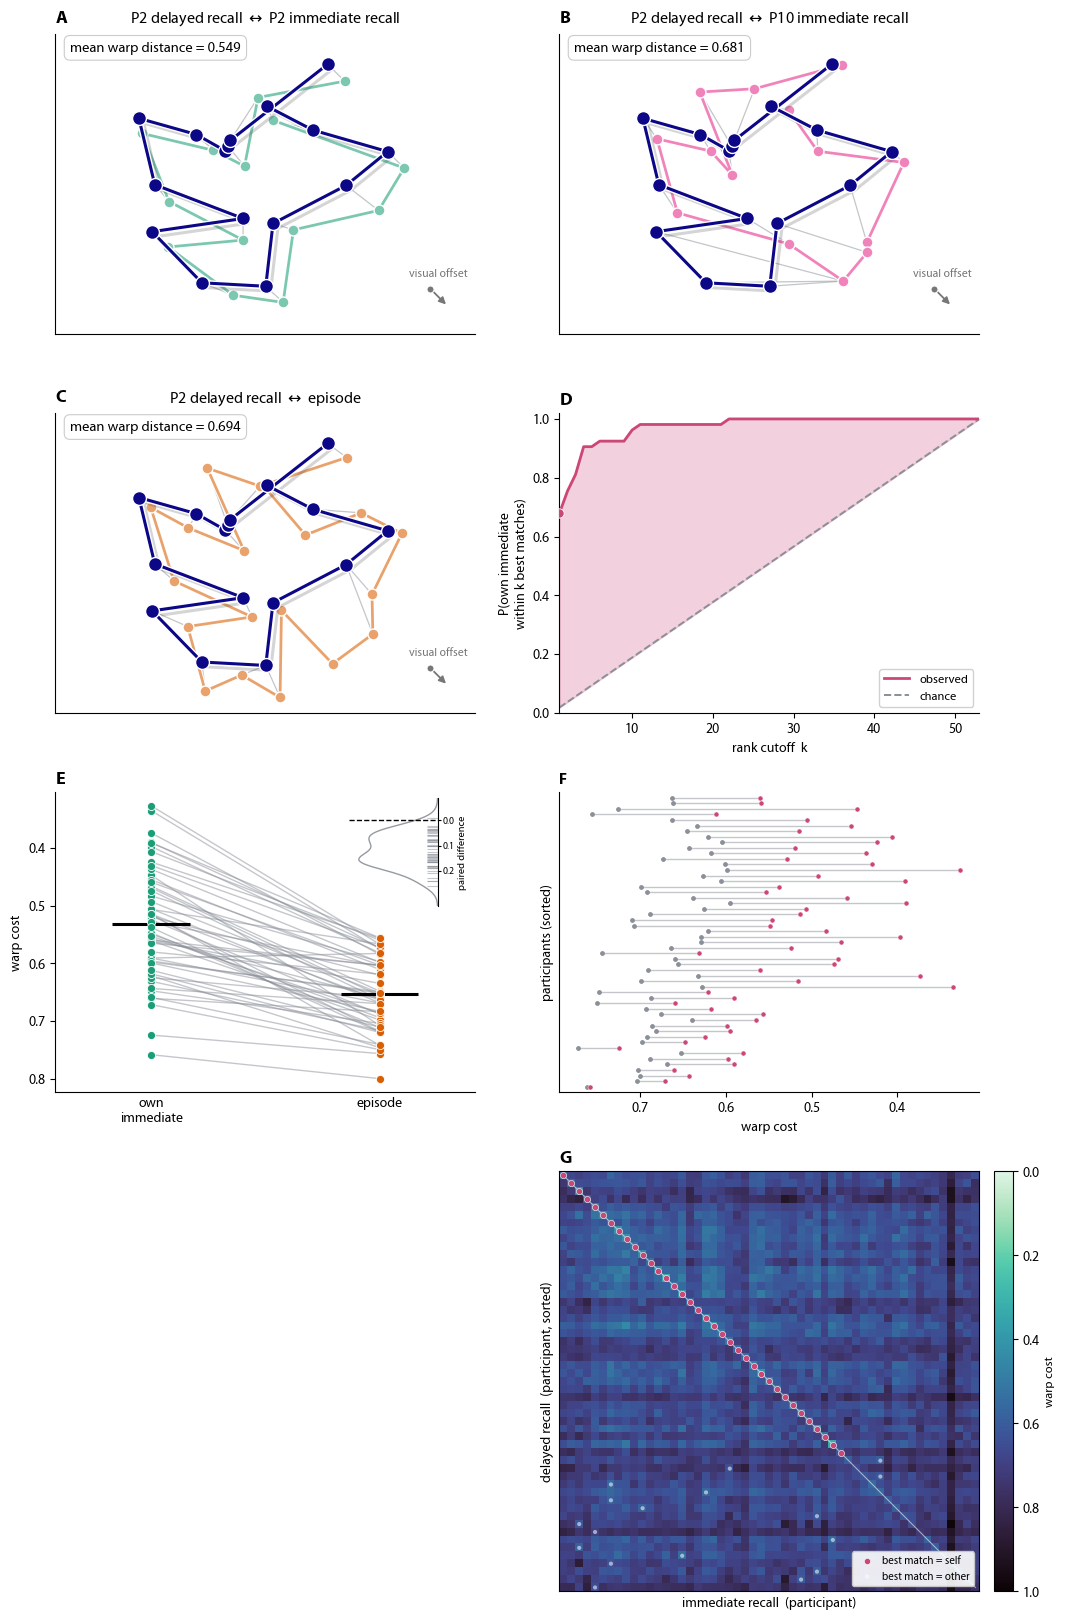

In [29]:
print(own_ax.get_window_extent().height / fig.dpi)  # old axes height in inches

2.999999999999998


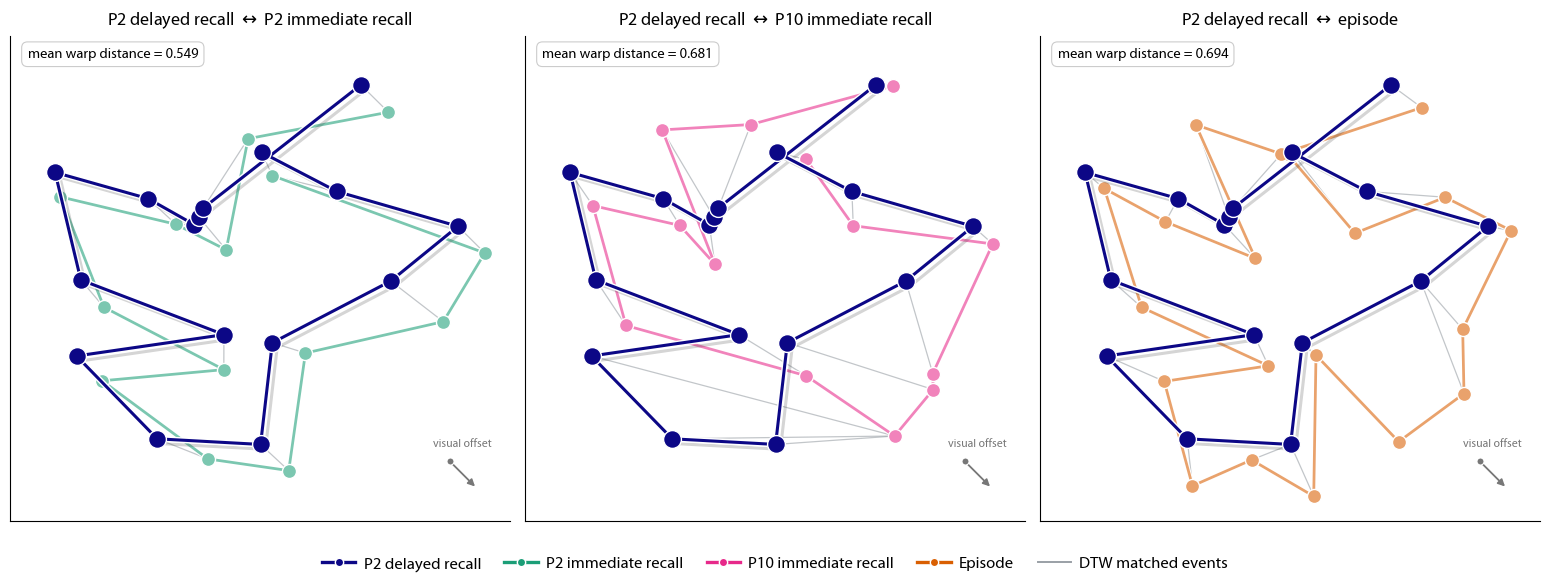

In [27]:
# ############################# STYLE CONFIG #############################

# MAIN_PARTICIPANT_N = 2
# OTHER_PARTICIPANT_N = 10 #15

# # ColorBrewer "Dark2" palette
# MAIN_DEL_COLOR = "#0c0786"#"#E7298A"
# MAIN_IMM_COLOR = "#1B9E77"
# OTHER_IMM_COLOR = "#E7298A"#"#7570B3"
# EPISODE_COLOR = "#D95F02"
# WARP_LINE_COLOR = "#9AA0A6"

# EVENT_MARKERSIZE = 165
# EVENT_BORDER_WIDTH = 1

# PATH_LINEWIDTH = 2.2
# PATH_CASING_WIDTH = PATH_LINEWIDTH + 2
# WARP_LINEWIDTH = 0.9
# WARP_LINE_ALPHA = 0.6
# CONNECTOR_ZORDER = 3.0            # above the back path, below the front path

# # --- depth effect ---
# DEPTH_OFFSET = (5.0, -5.0)        # (dx, dy) shift of the BACK path: right + down
# BACK_LIGHTEN = 0.42               # 0 = full colour, 1 = white (atmospheric recession)
# BACK_LW_SCALE = 0.9               # back path line a touch thinner
# BACK_MARKER_SCALE = 0.62          # back path markers smaller (further away)
# BACK_CASING_EXTRA = 1.5           # width of white casing beyond the line
# SHADOW_OFFSET = (3.5, -3.5)       # front-path drop shadow, in points
# SHADOW_COLOR = "#404040"
# SHADOW_ALPHA = 0.22

# # --- offset indicator ---
# SHOW_OFFSET_INDICATOR = True
# OFFSET_IND_COLOR = "#777777"
# OFFSET_IND_LABEL = "visual offset"


# XLIM_PAD = 5
# YLIM_PAD = 5

# TITLE_FONTSIZE = 13
# TITLE_YPAD = 8

# TEXTBOX_X = 0.035
# TEXTBOX_Y = 0.975
# TEXTBOX_FONTSIZE = 10.5

# ########################################################################

# main_participant = participants[MAIN_PARTICIPANT_N - 1]
# other_participant = participants[OTHER_PARTICIPANT_N - 1]

# main_pid = f'P{MAIN_PARTICIPANT_N}'
# other_pid = f'P{OTHER_PARTICIPANT_N}'

# del_path = main_participant.paths_2d['delayed']
# own_imm_path = main_participant.paths_2d['atlep1']
# other_imm_path = other_participant.paths_2d['atlep1']
# episode_path = atlep1.path_2d

# own_imm_dist, own_imm_warp = dtw(del_events_centered[MAIN_PARTICIPANT_N - 1], 
#                                  imm_events_centered[MAIN_PARTICIPANT_N - 1], 
#                                  metric='cosine', 
#                                  norm_cost=True)
# other_imm_dist, other_imm_warp = dtw(del_events_centered[MAIN_PARTICIPANT_N - 1], 
#                                      imm_events_centered[OTHER_PARTICIPANT_N - 1], 
#                                      metric='cosine', 
#                                      norm_cost=True)
# episode_dist, episode_warp = dtw(del_events_centered[MAIN_PARTICIPANT_N - 1], 
#                                  ep_events_centered, 
#                                  metric='cosine', 
#                                  norm_cost=True)


# # shared x,y-limits: include the shifted (back) paths so nothing clips
# offset = np.asarray(DEPTH_OFFSET)
# all_points = np.vstack((
#     del_path, own_imm_path, other_imm_path, episode_path,
#     del_path + offset, own_imm_path + offset,
#     other_imm_path + offset, episode_path + offset,
# ))

# xlim_min, ylim_min = all_points.min(axis=0)
# xlim_max, ylim_max = all_points.max(axis=0)
# xlim_min -= XLIM_PAD
# xlim_max += XLIM_PAD
# ylim_min -= YLIM_PAD
# ylim_max += YLIM_PAD


# fig = plt.figure(figsize=(15.6, 5.7))
# gs = fig.add_gridspec(nrows=1, ncols=6, hspace=0.28, wspace=0.55)

# own_ax = fig.add_subplot(gs[0, 0:2])
# other_ax = fig.add_subplot(gs[0, 2:4], sharex=own_ax, sharey=own_ax)
# ep_ax = fig.add_subplot(gs[0, 4:6], sharex=own_ax, sharey=own_ax)


# def style_panel(ax, title, dist):
#     ax.set_xlim(xlim_min, xlim_max)
#     ax.set_ylim(ylim_min, ylim_max)
#     ax.set(adjustable='box', aspect='equal', xticks=[], yticks=[])
#     ax.spines[['top', 'right']].set_visible(False)
#     ax.set_title(title, fontsize=TITLE_FONTSIZE, pad=TITLE_YPAD)
#     ax.text(TEXTBOX_X, TEXTBOX_Y, f'mean warp distance = {dist:.3f}',
#             transform=ax.transAxes, ha="left", va="top", fontsize=TEXTBOX_FONTSIZE,
#             bbox={'boxstyle': 'round,pad=0.4', 'fc': 'white', 'ec': '#cccccc', 'lw': 0.8})


# panels = [
#     (own_ax,   own_imm_path,   own_imm_warp,   MAIN_IMM_COLOR,
#      fr'{main_pid} delayed recall $\leftrightarrow$ {main_pid} immediate recall', own_imm_dist),
#     (other_ax, other_imm_path, other_imm_warp, OTHER_IMM_COLOR,
#      fr'{main_pid} delayed recall $\leftrightarrow$ {other_pid} immediate recall', other_imm_dist),
#     (ep_ax,    episode_path,   episode_warp,   EPISODE_COLOR,
#      fr'{main_pid} delayed recall $\leftrightarrow$ episode', episode_dist),
# ]

# for ax, comp_path, warp, comp_color, title, dist in panels:
#     front_path, front_color = del_path, MAIN_DEL_COLOR
#     back_path, back_color = comp_path, comp_color

#     # warp indices: a_ix -> delayed, b_ix -> comparison; shift whichever is the back path
#     del_is_back = False
#     del_draw = del_path + (offset if del_is_back else 0.0)
#     comp_draw = comp_path + (offset if not del_is_back else 0.0)

#     draw_dtw_matches(ax, del_draw, comp_draw, warp)                       # tie-lines
#     draw_event_path(ax, back_path, back_color, offset=DEPTH_OFFSET, back=True)   # back
#     draw_event_path(ax, front_path, front_color, back=False, shadow=True)        # front
#     if SHOW_OFFSET_INDICATOR:
#         draw_offset_indicator(ax, DEPTH_OFFSET)
#     style_panel(ax, title, dist)


# # shared legend
# handles = [
#     Line2D([0], [0], color=MAIN_DEL_COLOR, lw=2.4, marker="o", mfc=MAIN_DEL_COLOR,
#            mec="white", label=f"P{MAIN_PARTICIPANT_N} delayed recall"),
#     Line2D([0], [0], color=MAIN_IMM_COLOR, lw=2.4, marker="o", mfc=MAIN_IMM_COLOR,
#            mec="white", label=f"P{MAIN_PARTICIPANT_N} immediate recall"),
#     Line2D([0], [0], color=OTHER_IMM_COLOR, lw=2.4, marker="o", mfc=OTHER_IMM_COLOR,
#            mec="white", label=f"P{OTHER_PARTICIPANT_N} immediate recall"),
#     Line2D([0], [0], color=EPISODE_COLOR, lw=2.4, marker="o", mfc=EPISODE_COLOR,
#            mec="white", label="Episode"),
#     Line2D([0], [0], color=WARP_LINE_COLOR, lw=1.4, label="DTW matched events"),
# ]
# fig.legend(handles=handles, loc="lower center", ncol=7, frameon=False,
#            bbox_to_anchor=(0.5, -0.04), fontsize=12, handletextpad=0.5,
#            columnspacing=1.4)

# gs.tight_layout(fig)
# # fig.savefig(OUT_PATH, bbox_inches="tight", dpi=150)
# # print("saved", OUT_PATH)
# plt.show()

In [25]:
print(own_ax.get_window_extent().height / fig.dpi)  # old axes height in inches

4.859061835050757


In [96]:
#9AA0A6
n = warp_dists_self.shape[0]  # 53
warp_dists = np.empty((n, n), dtype=warp_dists_others.dtype)

off_diag = ~np.eye(n, dtype=bool)          # True everywhere except the diagonal
warp_dists[off_diag] = warp_dists_others.ravel()  # fill off-diagonals, row by row
np.fill_diagonal(warp_dists, warp_dists_self)     # set the diagonal

In [139]:
panel_data = {
    # --- 2D trajectories: each an (N_i, 2) float array of x,y coords ---
    'del_path':       del_path,
    'own_imm_path':   own_imm_path,  # P2 immediate recall
    'other_imm_path': other_imm_path,  # P10 immediate recall
    'episode_path':   episode_path,  # episode

    # --- DTW warp paths: each an iterable of (delayed_idx, comparison_idx) int pairs ---
    'own_imm_warp':   own_imm_warp,  # P2 delayed  <-> P2 immediate
    'other_imm_warp': other_imm_warp,  # P2 delayed  <-> P10 immediate
    'episode_warp':   episode_warp,  # P2 delayed  <-> episode

    # --- scalar mean warp distances (for the text boxes) ---
    'own_imm_dist':   own_imm_dist,  # float
    'other_imm_dist': other_imm_dist,  # float
    'episode_dist':   episode_dist,  # float
}

In [141]:
# import pickle
# with open('panel_data.p', 'wb') as f:
#     pickle.dump(panel_data, f)

In [13]:
# import numpy as np
# import matplotlib.pyplot as plt
# from matplotlib import gridspec

# warp_dists = np.load('warp_dists.npy')

# # ---- distance matrix; for DTW LOWER = more similar (a warp *cost*) ---------
# M = warp_dists
# n = M.shape[0]
# own = np.diag(M).copy()

# # sorting metric: pr small = well identified (own cost low relative to surrogates)
# pr = np.array([((own[i] > np.delete(M[i], i)).sum()
#                 + 0.5 * (own[i] == np.delete(M[i], i)).sum()) / (n - 1) for i in range(n)])
# order = np.argsort(pr)                # best-identified FIRST -> top-left of heatmap

# # ---- Panel B: tie-aware identification accuracy ---------------------------
# # your updated formula, flipped for cost: `below` = surrogates strictly MORE
# # similar (smaller cost) than own; ties unchanged. survival == P(own within top-k).
# ks = np.arange(1, n + 1)
# chance = ks / n
# below = np.array([(np.delete(M[i], i) < own[i]).sum() for i in range(n)])
# ties = np.array([(np.delete(M[i], i) == own[i]).sum() for i in range(n)])
# acc = np.array([np.mean(np.clip(k - below, 0, ties + 1) / (ties + 1)) for k in ks])

# # ---- style ----------------------------------------------------------------
# OWN = '#e4572e'; SUR = '#8a8f98'; FILL = '#f5c6b6'
# fig = plt.figure(figsize=(13, 6.2))
# gs = gridspec.GridSpec(2, 2, width_ratios=[1.05, 1.0], height_ratios=[1, 1],
#                        wspace=0.28, hspace=0.42, left=0.06, right=0.97, top=0.90, bottom=0.10)

# # ---- Panel A: identification matrix --------------------------------------
# axA = fig.add_subplot(gs[:, 0])
# Mo = M[np.ix_(order, order)]
# vmin, vmax = 0, 1 #warp_dists.min(), warp_dists.max()
# im = axA.imshow(Mo, cmap='mako_r', vmin=vmin, vmax=vmax, aspect='equal', interpolation='nearest')
# best = np.argmin(Mo, axis=1)          # lowest-cost match -> argmin
# diag_hit = best == np.arange(n)
# axA.plot([0, n - 1], [0, n - 1], color='w', lw=0.8, alpha=0.55, zorder=1)
# axA.scatter(best[diag_hit], np.arange(n)[diag_hit], s=20, c=OWN,
#             edgecolors='w', linewidths=0.4, zorder=3, label='best match = self')
# axA.scatter(best[~diag_hit], np.arange(n)[~diag_hit], s=9, c='w', alpha=0.55,
#             edgecolors='none', zorder=2, label='best match = other')
# axA.set_xlabel('immediate recall  (participant)')
# axA.set_ylabel('delayed recall  (participant, sorted)')
# axA.set_title('A', loc='left', fontweight='bold', fontsize=11)
# axA.set_xticks([]); axA.set_yticks([])
# cb = fig.colorbar(im, ax=axA, fraction=0.046, pad=0.02)
# cb.set_label('warp cost', fontsize=9)
# axA.legend(loc='lower right', fontsize=8, framealpha=0.9, handletextpad=0.3, borderpad=0.4)

# # ---- Panel B: identification / fingerprinting accuracy curve --------------
# axB = fig.add_subplot(gs[0, 1])
# axB.fill_between(range(1, n + 1), chance, acc, color=FILL, alpha=0.7, zorder=1)
# axB.plot(range(1, n + 1), acc, color=OWN, lw=2, zorder=3, label='observed')
# axB.plot(range(1, n + 1), chance, color=SUR, lw=1.4, ls='--', zorder=2, label='chance')
# axB.scatter([1], [acc[0]], s=45, c=OWN, zorder=4, edgecolors='w', linewidths=0.6)
# axB.set_xlabel('rank cutoff  k')
# axB.set_ylabel('P(own immediate\nwithin k best matches)')
# axB.set_xlim(1, n); axB.set_ylim(0, 1.02)
# axB.set_title('B', loc='left', fontweight='bold', fontsize=11)
# axB.legend(loc='lower right', fontsize=9, framealpha=0.9)
# axB.spines[['top', 'right']].set_visible(False)

# # ---- Panel C: own vs surrogate median, per participant --------------------
# axC = fig.add_subplot(gs[1, 1])

# for row, i in enumerate(order):
#     yy = n - 1 - row                  # best-identified (order[0]) at TOP
#     surr = np.delete(M[i], i)
#     med = np.median(surr)
#     axC.plot([med, own[i]], [yy, yy], color=SUR, lw=1.0, alpha=0.5, zorder=1)  # median -> own
#     axC.scatter(med, yy, s=6, c=SUR, zorder=2)
#     axC.scatter(own[i], yy, s=13, c=OWN if own[i] <= med else '#c9ccd1',
#                 edgecolors='w', linewidths=0.3, zorder=3)
# axC.set_xlabel('warp cost')
# axC.set_ylabel('participants (sorted)')
# axC.set_ylim(-1, n); axC.set_yticks([])
# axC.invert_xaxis()                    # low cost (better) to the RIGHT
# axC.set_title('C   Own immediate vs. others\' median per participant',
#               loc='left', fontweight='bold', fontsize=11)
# axC.spines[['top', 'right']].set_visible(False)

# # fig.savefig('recall_warp_fingerprint.png', dpi=200, bbox_inches='tight', facecolor='white')
# # print("saved; top-1=%.2f top-5=%.2f" % (acc[0], acc[4]))
# plt.show()